In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('/content/drive/MyDrive/Final_Year_Project/WindFarmA/0.csv', sep=';')
df_comma = pd.read_csv('/content/drive/MyDrive/Final_Year_Project/WindFarmA/comma_0.csv', sep=',')

df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df_comma['time_stamp'] = pd.to_datetime(df_comma['time_stamp'])

print(f'0.csv: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'comma_0.csv: {df_comma.shape[0]} rows, {df_comma.shape[1]} columns')

0.csv: 54986 rows, 86 columns
comma_0.csv: 54986 rows, 86 columns


In [ ]:
df.head()


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,2022-08-04 06:10:00,0,0,train,0,22.0,302.9,129.4,1.7,1.7,...,-496.0,0.0,0.0,-1280.0,-496.0,0.0,0.0,0.0,0.0,26.0
1,2022-08-04 06:20:00,0,1,train,0,22.0,307.1,133.6,1.7,1.7,...,-490.0,0.0,0.0,-1278.0,-490.0,0.0,0.0,0.0,0.0,25.0
2,2022-08-04 06:30:00,0,2,train,0,22.0,340.6,167.1,0.9,0.9,...,-490.0,0.0,0.0,-1356.0,-490.0,0.0,0.0,0.0,0.0,25.0
3,2022-08-04 06:40:00,0,3,train,0,22.0,124.4,-49.1,1.5,1.5,...,-509.0,0.0,0.0,-1274.0,-509.0,0.0,0.0,0.0,0.0,26.0
4,2022-08-04 06:50:00,0,4,train,0,22.0,66.2,-107.3,1.0,1.0,...,-499.0,0.0,0.0,-1284.0,-499.0,0.0,0.0,0.0,0.0,26.0


In [ ]:
print(f'Date range: {df["time_stamp"].min()} to {df["time_stamp"].max()}')
print(f'Reading interval: {df["time_stamp"].diff().mode()[0]}')
print(f'Turbine ID(s): {df["asset_id"].unique()}')
print(f'\nColumn types:')
print(df.dtypes.value_counts())

Date range: 2022-08-04 06:10:00 to 2023-08-24 06:10:00
Reading interval: 0 days 00:10:00
Turbine ID(s): [0]

Column types:
float64           81
int64              3
datetime64[ns]     1
object             1
Name: count, dtype: int64


In [ ]:
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.max() > 0 else  'Total nulls: ' + str(missing.sum()))

print(f'\nDuplicate rows: {df.duplicated().sum()}')

gaps = df['time_stamp'].diff()
big_gaps = gaps[gaps > pd.Timedelta('10min')]
print(f'Time gaps > 10 min: {len(big_gaps)}')
if len(big_gaps) > 0:
    print(f'Biggest gap: {big_gaps.max()}')

Missing values per column:
sensor_14_avg    1
sensor_22_avg    1
dtype: int64

Duplicate rows: 0
Time gaps > 10 min: 18
Biggest gap: 0 days 13:00:00


In [ ]:
num_cols = [c for c in df.columns if c not in ['time_stamp','asset_id','id','train_test','status_type_id']]
all_match = all(np.allclose(df[c].dropna(), df_comma[c].dropna(), equal_nan=True) for c in num_cols)
print(f"Identical: {all_match}")

print(f'Status codes in 0.csv')
print(df['status_type_id'].value_counts().sort_index())

print(f'\nStatus codes in comma_0.csv')
print(df_comma['status_type_id'].value_counts().sort_index())

Identical: True
Status codes in 0.csv
status_type_id
0    47540
3     1207
4     6239
Name: count, dtype: int64

Status codes in comma_0.csv
status_type_id
0    41514
3     1207
5    12265
Name: count, dtype: int64


In [ ]:
changes = df[df['status_type_id'] != df['status_type_id'].shift(1)]
labels = {0: 'NORMAL', 3: 'FAULT', 4: 'WARNING'}

for _, row in changes.iterrows():
    print(row["time_stamp"], row["status_type_id"])

statuses = changes['status_type_id'].tolist()
times = changes['time_stamp'].tolist()

for i, s in enumerate(statuses):
    if s == 4:
        nxt = statuses[i+1] if i+1 < len(statuses) else None
        dur = times[i+1] - times[i]
        print(nxt == 3, dur)

2022-08-04 06:10:00 0
2022-08-09 02:30:00 4
2022-08-23 02:30:00 3
2022-08-26 02:30:00 0
2023-06-03 11:40:00 4
2023-06-17 11:40:00 3
2023-06-20 11:40:00 0
2023-08-06 06:10:00 4
2023-08-21 14:50:00 3
True 14 days 00:00:00
True 14 days 00:00:00
True 15 days 08:40:00


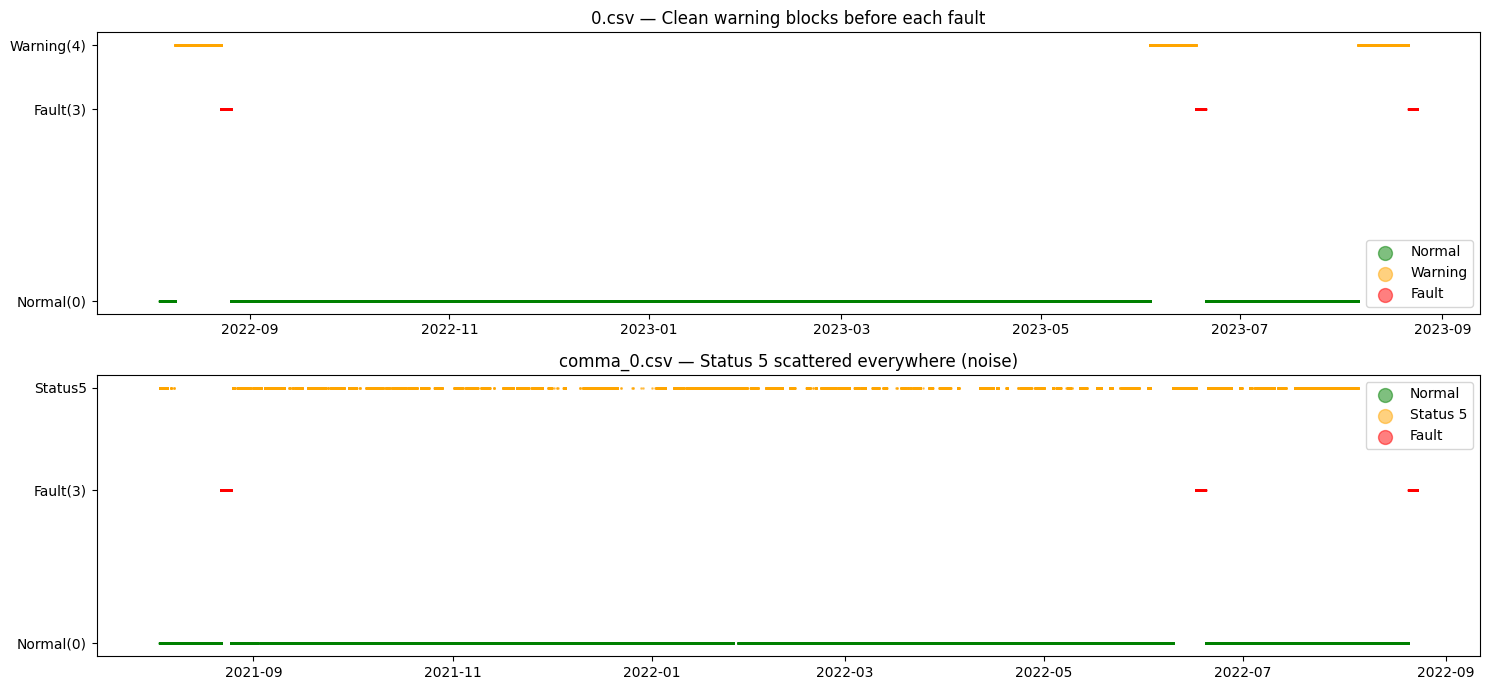

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7))


for s, c, l in [(0,'green','Normal'), (4,'orange','Warning'), (3,'red','Fault')]:
    m = df['status_type_id'] == s
    ax1.scatter(df.loc[m,'time_stamp'], df.loc[m,'status_type_id'], c=c, s=1, alpha=0.5, label=l)
ax1.set_title('0.csv — Clean warning blocks before each fault')
ax1.set_yticks([0,3,4])
ax1.set_yticklabels(['Normal(0)','Fault(3)','Warning(4)'])
ax1.legend(markerscale=10)


for s, c, l in [(0,'green','Normal'), (5,'orange','Status 5'), (3,'red','Fault')]:
    m = df_comma['status_type_id'] == s
    ax2.scatter(df_comma.loc[m,'time_stamp'], df_comma.loc[m,'status_type_id'], c=c, s=1, alpha=0.5, label=l)
ax2.set_title('comma_0.csv — Status 5 scattered everywhere (noise)')
ax2.set_yticks([0,3,5])
ax2.set_yticklabels(['Normal(0)','Fault(3)','Status5'])
ax2.legend(markerscale=10)

plt.tight_layout()
plt.show()

In [ ]:
df.describe().round(2)

,time_stamp,asset_id,id,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,wind_speed_3_max,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
count,54986,54986.0,54986.00,54986.00,54986.00,54986.00,54986.00,54986.00,54986.00,54986.00,...,54986.00,54986.00,54986.0,54986.00,54986.00,54986.00,54986.00,54986.00,54986.00,54986.00
mean,2023-02-12 19:09:52.514458112,0.0,27492.50,0.52,20.15,164.70,0.84,6.53,6.49,14.38,...,-474.03,-15692.63,0.0,98527.09,-16166.65,9.39,10.43,8.30,0.58,23.18
min,2022-08-04 06:10:00,0.0,0.00,0.00,4.00,0.00,-179.80,0.50,0.00,0.80,...,-5201.00,-80419.00,0.0,-5126.00,-80419.00,0.00,0.00,0.00,0.00,8.00
25%,2022-11-09 07:12:30,0.0,13746.25,0.00,16.00,93.20,-10.40,3.30,3.30,7.60,...,-507.00,-28430.00,0.0,-633.75,-28432.75,2.40,2.70,1.70,0.10,18.00
50%,2023-02-12 19:55:00,0.0,27492.50,0.00,20.00,120.55,0.60,5.60,5.60,12.50,...,0.00,-16008.00,0.0,38097.00,-16018.50,11.40,12.60,10.90,0.20,23.00
75%,2023-05-19 08:07:30,0.0,41238.75,0.00,24.00,252.80,9.80,9.00,9.00,20.10,...,0.00,0.00,0.0,181624.75,-2147.25,14.30,14.90,12.90,0.60,27.00
max,2023-08-24 06:10:00,0.0,54985.00,4.00,41.00,359.00,180.00,25.50,25.50,70.00,...,381.00,81778.00,0.0,334355.00,81772.00,14.90,16.90,14.80,7.30,45.00
std,NaN,0.0,15873.24,1.32,5.75,91.62,32.54,3.99,3.91,8.46,...,905.31,13652.95,0.0,120238.28,13136.38,5.62,5.79,5.67,1.00,5.95


Class 0 (Normal): 47,540 (88.4%)
Class 1 (Warning): 6,239 (11.6%)
Imbalance ratio: 7.6 : 1


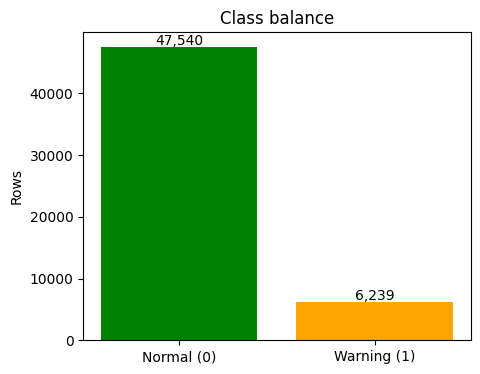

In [ ]:

df_bin = df[df['status_type_id'] != 3].copy()
df_bin['target'] = (df_bin['status_type_id'] == 4).astype(int)

counts = df_bin['target'].value_counts()
print(f'Class 0 (Normal): {counts[0]:,} ({counts[0]/len(df_bin)*100:.1f}%)')
print(f'Class 1 (Warning): {counts[1]:,} ({counts[1]/len(df_bin)*100:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f} : 1')

plt.figure(figsize=(5, 4))
plt.bar(['Normal (0)', 'Warning (1)'], [counts[0], counts[1]], color=['green','orange'])
plt.ylabel('Rows')
plt.title('Class balance')
for i, v in enumerate([counts[0], counts[1]]):
    plt.text(i, v + 300, f'{v:,}', ha='center')
plt.show()

Temperature: 40
Wind & Directional: 5
Rotational Speed: 8
Electrical: 25
Energy Counters: 3
Total: 81


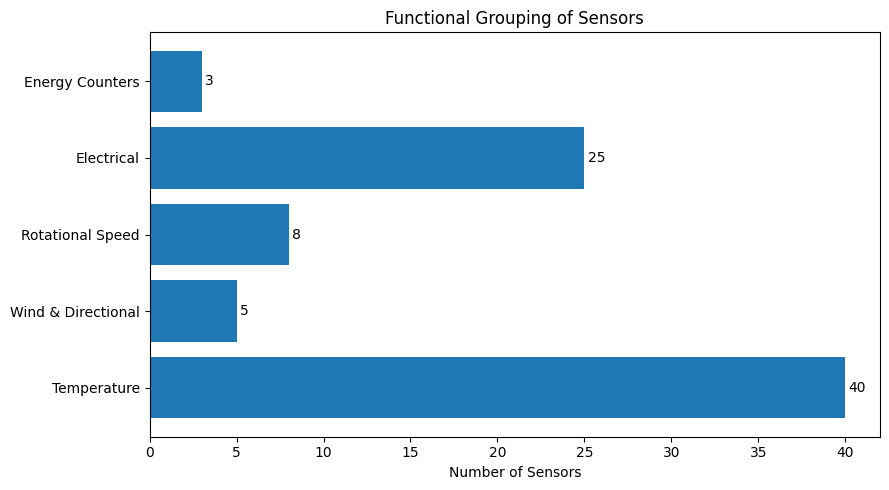

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Final_Year_Project/WindFarmA/0.csv', sep=';')

meta_cols = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
sensor_cols = [c for c in df.columns if c not in meta_cols]

roots = set()
for c in sensor_cols:
    for suffix in ['_avg', '_max', '_min', '_std']:
        if c.endswith(suffix):
            roots.add(c[:-len(suffix)])
            break
    else:
        roots.add(c)

temperature = [c for c in sensor_cols if c not in
               [col for col in sensor_cols if
                any(col.startswith(p) for p in
                    ['wind_speed_', 'power_', 'reactive_power_'])] and
               not any(c.startswith(r) for r in
                    ['sensor_18', 'sensor_52',
                     'sensor_23', 'sensor_25', 'sensor_34',
                     'sensor_35', 'sensor_36', 'sensor_37',
                     'sensor_38', 'sensor_39', 'sensor_40',
                     'sensor_44', 'sensor_48', 'sensor_50'])]

wind_directional = [c for c in sensor_cols if c.startswith('wind_speed_')]

electrical = [c for c in sensor_cols if any(c.startswith(p) for p in
               ['power_', 'reactive_power_', 'sensor_23', 'sensor_25',
                'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37',
                'sensor_38', 'sensor_39', 'sensor_40'])]

rotational = [c for c in sensor_cols if any(c.startswith(r) for r in
               ['sensor_18', 'sensor_52'])]

energy_counters = [c for c in sensor_cols if any(c.startswith(r) for r in
                    ['sensor_44', 'sensor_48', 'sensor_50'])]

groups = {
    'Temperature': len(temperature),
    'Wind & Directional': len(wind_directional),
    'Rotational Speed': len(rotational),
    'Electrical': len(electrical),
    'Energy Counters': len(energy_counters),
}

for k, v in groups.items():
    print(f"{k}: {v}")
print(f"Total: {sum(groups.values())}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(list(groups.keys()), list(groups.values()))
ax.set_xlabel('Number of Sensors')
ax.set_title('Functional Grouping of Sensors')

for i, v in enumerate(groups.values()):
    ax.text(v + 0.2, i, str(v), va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final_Year_Project/Results/figure_3_3_sensor_groups.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print(f"Total columns: {df.shape[1]}")
print(f"Sensor columns: {len(sensor_cols)}")
print(sensor_cols[:20])

Total columns: 86
Sensor columns: 81
['sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max', 'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max', 'sensor_5_min', 'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg', 'sensor_8_avg', 'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg', 'sensor_12_avg', 'sensor_13_avg']


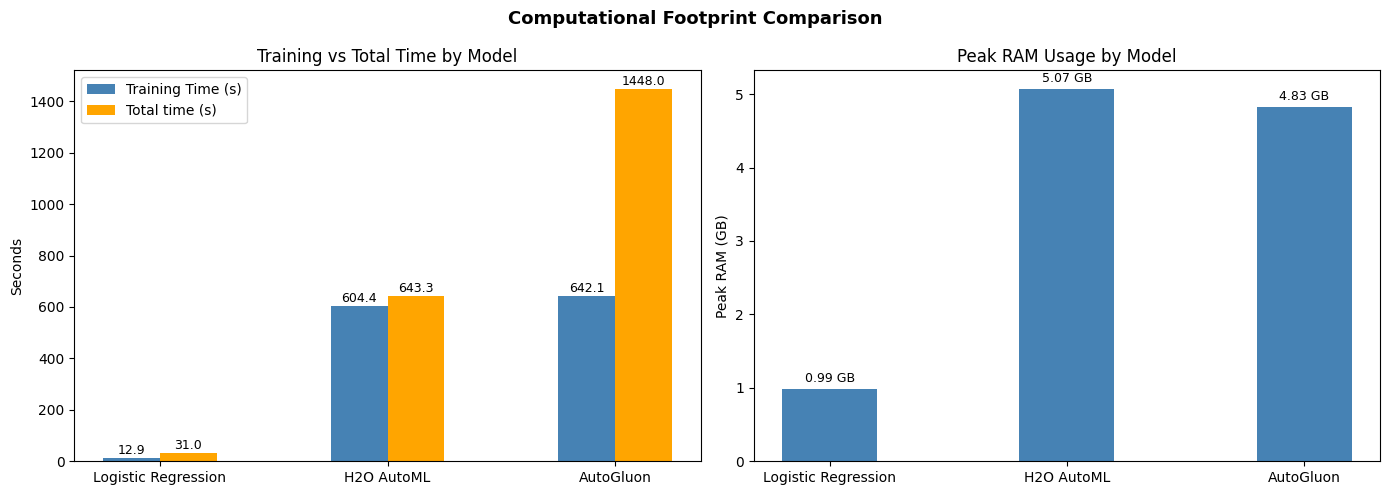

In [5]:
models = ['Logistic Regression', 'H2O AutoML', 'AutoGluon']
train_times = [12.9, 604.4, 642.1]
total_times = [31.0, 643.3, 1448.0]
ram = [0.99, 5.07, 4.83]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax = axes[0]
bars1 = ax.bar(x - width/2, train_times, width, label='Training Time (s)', color='steelblue')
bars2 = ax.bar(x + width/2, total_times, width, label='Total time (s)', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Seconds')
ax.set_title('Training vs Total Time by Model')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)


ax = axes[1]
bars = ax.bar(x, ram, 0.4, color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Peak RAM (GB)')
ax.set_title('Peak RAM Usage by Model')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f} GB', ha='center', va='bottom', fontsize=9)

plt.suptitle('Computational Footprint Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final_Year_Project/Results/figure_5_4_compute.png',
            dpi=150, bbox_inches='tight')
plt.show()
